# Advanced Frog Species Prediction Model
## Using TerraClimate Variables for Binary Classification

This notebook builds a machine learning classification model to predict frog species presence based on TerraClimate climate variables. The model uses advanced feature engineering, multiple algorithms, and proper cross-validation to achieve high F1 Score performance.

## Section 1: Import Required Libraries

Import necessary libraries for data science, machine learning, and data manipulation.

In [60]:
import warnings
warnings.filterwarnings('ignore')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib
import os

# Machine Learning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

# Gradient boosting libraries
import lightgbm as lgb
import xgboost as xgb
import optuna

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CatBoostClassifier = None
    CATBOOST_AVAILABLE = False
    print("CatBoost is not installed yet. The CatBoost blend block will be skipped unless you install it.")

# For climate data
import xarray as xr
import rasterio

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("All libraries imported successfully!")
print(f"CatBoost available: {CATBOOST_AVAILABLE}")

All libraries imported successfully!
CatBoost available: True


## Section 2: Load and Explore the Data

Load the training and test datasets from CSV files and understand their structure.

In [61]:
# Load training and test data
train_data = pd.read_csv('Training_Data.csv')
test_data = pd.read_csv('Test.csv')

print("Training Data Shape:", train_data.shape)
print("\nTraining Data Info:")
print(train_data.head())
print("\nTarget Distribution:")
print(train_data['Occurrence Status'].value_counts())
print("\nClass Balance:")
print(train_data['Occurrence Status'].value_counts(normalize=True))

print("\n" + "="*50)
print("Test Data Shape:", test_data.shape)
print("Test Data Info:")
print(test_data.head())

Training Data Shape: (6312, 4)

Training Data Info:
             ID   Latitude   Longitude  Occurrence Status
0  ID_TR_957A5A -34.027900  150.771000                  1
1  ID_TR_55E0AF -34.821595  147.193697                  1
2  ID_TR_7AC931 -36.617759  146.882941                  0
3  ID_TR_7D3CE4 -37.470900  144.744000                  1
4  ID_TR_02F669 -38.400153  145.018560                  1

Target Distribution:
Occurrence Status
1    3792
0    2520
Name: count, dtype: int64

Class Balance:
Occurrence Status
1    0.60076
0    0.39924
Name: proportion, dtype: float64

Test Data Shape: (2000, 3)
Test Data Info:
             ID   Latitude   Longitude
0  ID_TS_54240C -33.121788  150.320746
1  ID_TS_EF9635 -36.592011  148.172262
2  ID_TS_4E63E6 -35.455100  146.693465
3  ID_TS_FDAB8E -33.076261  149.547177
4  ID_TS_E00D49 -35.529729  146.627272


## Section 3: Extract TerraClimate Variables

Define a function to extract TerraClimate climate variables from GeoTIFF files using lat/lon coordinates.

In [62]:
def extract_climate_features(tiff_path, csv_df, band_names):
    """
    Fast extraction of ALL climate bands from the GeoTIFF using rasterio sampling.
    Reads band_names from band_names.json generated by TerraClimate.ipynb.
    """
    with rasterio.open(tiff_path) as dataset:
        available_band_count = dataset.count
        usable_band_names = band_names[:available_band_count]
        if len(band_names) > available_band_count:
            print(
                f"Warning: GeoTIFF has only {available_band_count} bands but {len(band_names)} names were supplied. "
                "Truncating to available bands."
            )

        coords = list(zip(csv_df["Longitude"].values, csv_df["Latitude"].values))
        sampled = np.array(list(dataset.sample(coords)), dtype=np.float32)

    extracted = pd.DataFrame(sampled, columns=usable_band_names)
    extracted = extracted.replace([np.inf, -np.inf], np.nan)
    return extracted


# Load band names from JSON (generated by TerraClimate.ipynb)
tiff_path = 'TerraClimate_output.tiff'
band_names_file = 'band_names.json'

if os.path.exists(tiff_path) and os.path.exists(band_names_file):
    with open(band_names_file) as f:
        band_names = json.load(f)
    print(f"GeoTIFF found with {len(band_names)} bands: {band_names}")

    train_climate = extract_climate_features(tiff_path, train_data, band_names)
    test_climate = extract_climate_features(tiff_path, test_data, band_names)

    print(f"\nTrain climate shape: {train_climate.shape}")
    print(f"Test climate shape:  {test_climate.shape}")
    print(train_climate.describe())
elif os.path.exists(tiff_path):
    with rasterio.open(tiff_path) as src:
        n_bands = src.count
    band_names = [f"band_{i}" for i in range(1, n_bands + 1)]
    print(f"No band_names.json found. Reading {n_bands} bands with generic names.")

    train_climate = extract_climate_features(tiff_path, train_data, band_names)
    test_climate = extract_climate_features(tiff_path, test_data, band_names)
else:
    print("ERROR: TerraClimate_output.tiff not found!")
    print("Please run TerraClimate.ipynb first to generate the GeoTIFF.")
    train_climate = pd.DataFrame()
    test_climate = pd.DataFrame()

GeoTIFF found with 187 bands: ['aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std', 'ppt_wet_median', 'soil_wet_median', 'aet_wet_median', 'pet_wet_median', 'tmax_wet_median', 'tmin_wet_median', 'vpd_wet_median', 'vap_wet_median', 'ws_wet_median', 'ppt_dry_median', 'soil_dry_median', 'aet_dry_median', 'pet_dry_median', 'tmax_dry_median', 'tmin_dry_median', 'vpd_dry_median', 'vap_dry_median', 'ws_dry_median', 'ppt_wet_std', 'soil_wet_std', 'aet_wet_std', 'pet_wet_std', 'tmax_wet_std', 'tmin_wet_std', 'vpd_wet_std', 'vap_wet_std', 'ws_wet_std', 'ppt_dry_std', 'soil_dry_std', 'aet_dry_std', 'pet_dry_std', 'tmax_dry_std', 'tmin_dry_std', 'vpd_dry_std', 'vap_dry_std', 'ws_dry_std', 'ppt_q1_media

## Section 4: Preprocess and Engineer Features

Combine climate features with ground truth data, handle missing values, and prepare features for modeling.

In [63]:
def create_combined_dataset(climate_df, ground_df, include_coords=True):
    """Combine climate features with ground truth data, optionally keep lat/lon as features."""
    combined = pd.concat([ground_df.reset_index(drop=True), climate_df.reset_index(drop=True)], axis=1)

    # Fill missing climate values with column median
    numeric_cols = combined.select_dtypes(include=[np.number]).columns
    combined[numeric_cols] = combined[numeric_cols].fillna(combined[numeric_cols].median())

    if not include_coords:
        combined = combined.drop(columns=['Latitude', 'Longitude'], errors='ignore')

    return combined


# Build combined datasets — KEEP lat/lon as features (geographic position is predictive)
if len(train_climate) > 0:
    X_train_combined = create_combined_dataset(train_climate, train_data, include_coords=True)
    X_test_combined = create_combined_dataset(test_climate, test_data, include_coords=True)
else:
    X_train_combined = train_data.copy()
    X_test_combined = test_data.copy()

print("Combined Training Data Shape:", X_train_combined.shape)
print("Columns:", X_train_combined.columns.tolist())

Combined Training Data Shape: (6312, 191)
Columns: ['ID', 'Latitude', 'Longitude', 'Occurrence Status', 'aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std', 'ppt_wet_median', 'soil_wet_median', 'aet_wet_median', 'pet_wet_median', 'tmax_wet_median', 'tmin_wet_median', 'vpd_wet_median', 'vap_wet_median', 'ws_wet_median', 'ppt_dry_median', 'soil_dry_median', 'aet_dry_median', 'pet_dry_median', 'tmax_dry_median', 'tmin_dry_median', 'vpd_dry_median', 'vap_dry_median', 'ws_dry_median', 'ppt_wet_std', 'soil_wet_std', 'aet_wet_std', 'pet_wet_std', 'tmax_wet_std', 'tmin_wet_std', 'vpd_wet_std', 'vap_wet_std', 'ws_wet_std', 'ppt_dry_std', 'soil_dry_std', 'aet_dry_std', 'pet_dry_std', 'tmax_dry_std', 

In [64]:
# Prepare X and y — include Latitude/Longitude as features, exclude ID and target
exclude_cols = ['ID', 'Occurrence Status']
feature_cols = [c for c in X_train_combined.columns if c not in exclude_cols]

X = X_train_combined[feature_cols].copy()
y = X_train_combined['Occurrence Status'].copy()

test_ids = X_test_combined['ID'].copy()
X_test_final = X_test_combined[feature_cols].copy()

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Training: {X.shape}, Test: {X_test_final.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1")

Features (189): ['Latitude', 'Longitude', 'aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std', 'ppt_wet_median', 'soil_wet_median', 'aet_wet_median', 'pet_wet_median', 'tmax_wet_median', 'tmin_wet_median', 'vpd_wet_median', 'vap_wet_median', 'ws_wet_median', 'ppt_dry_median', 'soil_dry_median', 'aet_dry_median', 'pet_dry_median', 'tmax_dry_median', 'tmin_dry_median', 'vpd_dry_median', 'vap_dry_median', 'ws_dry_median', 'ppt_wet_std', 'soil_wet_std', 'aet_wet_std', 'pet_wet_std', 'tmax_wet_std', 'tmin_wet_std', 'vpd_wet_std', 'vap_wet_std', 'ws_wet_std', 'ppt_dry_std', 'soil_dry_std', 'aet_dry_std', 'pet_dry_std', 'tmax_dry_std', 'tmin_dry_std', 'vpd_dry_std', 'vap_dry_std', 'ws_dry_std', 'p

## Section 4b: Spatial KNN Features

Compute occurrence-based spatial features using K-Nearest Neighbors with haversine distance. This captures the strong spatial autocorrelation of frog presence — nearby locations tend to have similar occurrence patterns.

In [65]:
# ============================================================
# SPATIAL KNN FEATURES + FOLD-SAFE SPATIAL PRIORS
# ============================================================
from sklearn.neighbors import BallTree

print("=" * 60)
print("COMPUTING SPATIAL FEATURES")
print("=" * 60)

def compute_knn_features(ref_coords, ref_labels, query_coords, k_values=[3, 5, 10, 25, 50, 100],
                          exclude_self=False):
    """
    Compute KNN-based spatial features using haversine distance.
    """
    ref_arr = ref_coords[['Latitude', 'Longitude']].values
    query_arr = query_coords[['Latitude', 'Longitude']].values
    ref_rad = np.radians(ref_arr)
    query_rad = np.radians(query_arr)
    labels_arr = ref_labels.values if hasattr(ref_labels, 'values') else np.array(ref_labels)

    tree = BallTree(ref_rad, metric='haversine')
    max_k = max(k_values) + (1 if exclude_self else 0)
    max_k = min(max_k, len(ref_rad))
    distances, indices = tree.query(query_rad, k=max_k)

    offset = 1 if exclude_self else 0
    distances_km = distances * 6371.0

    features = {}
    for k in k_values:
        if k + offset > distances.shape[1]:
            continue
        k_dists = distances_km[:, offset:k+offset]
        k_idx = indices[:, offset:k+offset]
        k_labels = labels_arr[k_idx]

        features[f'knn_{k}_occ_mean'] = k_labels.mean(axis=1)
        features[f'knn_{k}_occ_std'] = k_labels.std(axis=1)
        features[f'knn_{k}_dist_mean'] = k_dists.mean(axis=1)
        features[f'knn_{k}_dist_min'] = k_dists[:, 0]
        features[f'knn_{k}_weighted_occ'] = np.average(
            k_labels, axis=1, weights=1.0 / (k_dists + 0.01)
        )

    for label_val, label_name in [(1, 'pos'), (0, 'neg')]:
        mask = labels_arr == label_val
        if mask.sum() < 2:
            continue
        sub_rad = ref_rad[mask]
        sub_tree = BallTree(sub_rad, metric='haversine')

        if exclude_self:
            sub_dist, _ = sub_tree.query(query_rad, k=min(2, mask.sum()))
            is_same = np.zeros(len(query_rad), dtype=bool)
            if len(labels_arr) == len(query_rad):
                is_same = labels_arr == label_val
            features[f'dist_nearest_{label_name}_km'] = np.where(
                is_same,
                sub_dist[:, min(1, sub_dist.shape[1]-1)] * 6371.0,
                sub_dist[:, 0] * 6371.0
            )
        else:
            sub_dist, _ = sub_tree.query(query_rad, k=1)
            features[f'dist_nearest_{label_name}_km'] = sub_dist[:, 0] * 6371.0

    if 'dist_nearest_pos_km' in features and 'dist_nearest_neg_km' in features:
        features['dist_ratio_pos_neg'] = (
            features['dist_nearest_pos_km'] / (features['dist_nearest_neg_km'] + 0.01)
        )
        features['dist_diff_pos_neg'] = (
            features['dist_nearest_pos_km'] - features['dist_nearest_neg_km']
        )

    return pd.DataFrame(features)


def add_spatial_prior_features(train_df, train_labels, test_df, cv_splits=5, random_state=42, n_clusters=40):
    """
    Build fold-safe spatial prior features using coarse spatial bins and unsupervised clusters.
    These are target-mean priors computed OOF for the training set and from full data for test.
    """
    train_coords = train_df[['Latitude', 'Longitude']].reset_index(drop=True).copy()
    test_coords = test_df[['Latitude', 'Longitude']].reset_index(drop=True).copy()
    y_arr = pd.Series(train_labels).reset_index(drop=True)
    global_rate = float(y_arr.mean())

    def build_meta(coords_df, clusterer=None):
        meta = pd.DataFrame(index=coords_df.index)
        meta['lat_bin_025'] = np.round(coords_df['Latitude'] / 0.25) * 0.25
        meta['lon_bin_025'] = np.round(coords_df['Longitude'] / 0.25) * 0.25
        meta['lat_bin_050'] = np.round(coords_df['Latitude'] / 0.50) * 0.50
        meta['lon_bin_050'] = np.round(coords_df['Longitude'] / 0.50) * 0.50
        meta['grid_025'] = meta['lat_bin_025'].astype(str) + '_' + meta['lon_bin_025'].astype(str)
        meta['grid_050'] = meta['lat_bin_050'].astype(str) + '_' + meta['lon_bin_050'].astype(str)
        if clusterer is not None:
            meta['cluster_id'] = clusterer.predict(coords_df[['Latitude', 'Longitude']])
        return meta

    derived_clusters = max(8, min(n_clusters, len(train_coords) // 120 if len(train_coords) // 120 > 0 else 8))
    clusterer = KMeans(n_clusters=derived_clusters, random_state=random_state, n_init=10)
    clusterer.fit(train_coords[['Latitude', 'Longitude']])

    train_meta = build_meta(train_coords, clusterer)
    test_meta = build_meta(test_coords, clusterer)

    prior_cols = ['grid_025', 'grid_050', 'cluster_id']
    train_prior = pd.DataFrame(index=train_meta.index)
    test_prior = pd.DataFrame(index=test_meta.index)

    skf_spatial = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    for tr_idx, va_idx in skf_spatial.split(train_coords, y_arr):
        fold_train = train_meta.iloc[tr_idx].copy()
        fold_train['target'] = y_arr.iloc[tr_idx].values
        fold_valid = train_meta.iloc[va_idx].copy()

        for col in prior_cols:
            agg = fold_train.groupby(col)['target'].agg(['mean', 'count'])
            train_prior.loc[va_idx, f'{col}_target_mean'] = fold_valid[col].map(agg['mean']).fillna(global_rate).values
            train_prior.loc[va_idx, f'{col}_target_count'] = fold_valid[col].map(agg['count']).fillna(0).values

    full_meta = train_meta.copy()
    full_meta['target'] = y_arr.values
    for col in prior_cols:
        agg = full_meta.groupby(col)['target'].agg(['mean', 'count'])
        test_prior[f'{col}_target_mean'] = test_meta[col].map(agg['mean']).fillna(global_rate).values
        test_prior[f'{col}_target_count'] = test_meta[col].map(agg['count']).fillna(0).values

    rename_map = {
        'grid_025_target_mean': 'spatial_prior_grid025',
        'grid_050_target_mean': 'spatial_prior_grid050',
        'cluster_id_target_mean': 'spatial_prior_cluster',
        'grid_025_target_count': 'spatial_density_grid025',
        'grid_050_target_count': 'spatial_density_grid050',
        'cluster_id_target_count': 'spatial_density_cluster',
    }
    train_prior = train_prior.rename(columns=rename_map)
    test_prior = test_prior.rename(columns=rename_map)

    for df in [train_prior, test_prior]:
        df['spatial_prior_mean'] = df[[
            'spatial_prior_grid025', 'spatial_prior_grid050', 'spatial_prior_cluster'
        ]].mean(axis=1)
        df['spatial_density_mean'] = np.log1p(df[[
            'spatial_density_grid025', 'spatial_density_grid050', 'spatial_density_cluster'
        ]].mean(axis=1))

    return train_prior.fillna(global_rate), test_prior.fillna(global_rate)


# Compute spatial KNN features
train_coords = X[['Latitude', 'Longitude']]
test_coords = X_test_final[['Latitude', 'Longitude']]

print("Computing KNN features for training data (leave-one-out)...")
train_knn = compute_knn_features(X, y, X, exclude_self=True)

print("Computing KNN features for test data...")
test_knn = compute_knn_features(X, y, X_test_final, exclude_self=False)

print("Computing fold-safe spatial prior features...")
train_spatial_prior, test_spatial_prior = add_spatial_prior_features(X, y, X_test_final)

# Append spatial features
X = pd.concat([
    X.reset_index(drop=True),
    train_knn.reset_index(drop=True),
    train_spatial_prior.reset_index(drop=True)
], axis=1)
X_test_final = pd.concat([
    X_test_final.reset_index(drop=True),
    test_knn.reset_index(drop=True),
    test_spatial_prior.reset_index(drop=True)
], axis=1)

feature_cols = X.columns.tolist()

print(f"\nKNN features added ({len(train_knn.columns)}): {train_knn.columns.tolist()}")
print(f"Spatial prior features added ({len(train_spatial_prior.columns)}): {train_spatial_prior.columns.tolist()}")
print(f"Total features now: {len(feature_cols)}")
print(f"Training shape: {X.shape}, Test shape: {X_test_final.shape}")
print("\nSample spatial prior values:")
print(train_spatial_prior.head())

COMPUTING SPATIAL FEATURES
Computing KNN features for training data (leave-one-out)...


Computing KNN features for test data...
Computing fold-safe spatial prior features...

KNN features added (34): ['knn_3_occ_mean', 'knn_3_occ_std', 'knn_3_dist_mean', 'knn_3_dist_min', 'knn_3_weighted_occ', 'knn_5_occ_mean', 'knn_5_occ_std', 'knn_5_dist_mean', 'knn_5_dist_min', 'knn_5_weighted_occ', 'knn_10_occ_mean', 'knn_10_occ_std', 'knn_10_dist_mean', 'knn_10_dist_min', 'knn_10_weighted_occ', 'knn_25_occ_mean', 'knn_25_occ_std', 'knn_25_dist_mean', 'knn_25_dist_min', 'knn_25_weighted_occ', 'knn_50_occ_mean', 'knn_50_occ_std', 'knn_50_dist_mean', 'knn_50_dist_min', 'knn_50_weighted_occ', 'knn_100_occ_mean', 'knn_100_occ_std', 'knn_100_dist_mean', 'knn_100_dist_min', 'knn_100_weighted_occ', 'dist_nearest_pos_km', 'dist_nearest_neg_km', 'dist_ratio_pos_neg', 'dist_diff_pos_neg']
Spatial prior features added (8): ['spatial_prior_grid025', 'spatial_density_grid025', 'spatial_prior_grid050', 'spatial_density_grid050', 'spatial_prior_cluster', 'spatial_density_cluster', 'spatial_prior_mea

## Section 5: Split Data into Training and Validation Sets

Partition the training data into train and validation subsets using stratified split to maintain class balance.

In [66]:
# Stratified train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape},  Val: {X_val.shape}")
print(f"Train dist:\n{y_train.value_counts(normalize=True)}")
print(f"Val dist:\n{y_val.value_counts(normalize=True)}")

Train: (5049, 231),  Val: (1263, 231)
Train dist:
Occurrence Status
1    0.600713
0    0.399287
Name: proportion, dtype: float64
Val dist:
Occurrence Status
1    0.60095
0    0.39905
Name: proportion, dtype: float64


## Section 6: Feature Engineering

Create derived features from climate variables to improve model discrimination.

In [ ]:
def engineer_features(df, base_feature_cols):
    """Create derived features from climate, seasonal, quarterly, spatial, and KNN columns."""
    out = df.copy()

    excluded_prefixes = ('knn_', 'dist_', 'spatial_prior_', 'spatial_density_')
    climate_cols = [
        c for c in base_feature_cols
        if c not in ['Latitude', 'Longitude'] and not c.startswith(excluded_prefixes)
    ]
    median_cols = [c for c in climate_cols if c.endswith('_median')]
    std_cols = [c for c in climate_cols if c.endswith('_std')]

    def has_cols(*cols):
        return all(col in out.columns for col in cols)

    # 1. Aggregate statistics across climate features
    if len(climate_cols) >= 2:
        out['climate_mean'] = out[climate_cols].mean(axis=1)
        out['climate_std'] = out[climate_cols].std(axis=1)
        out['climate_range'] = out[climate_cols].max(axis=1) - out[climate_cols].min(axis=1)
        out['climate_cv'] = out['climate_std'] / (out['climate_mean'].abs() + 1e-8)
        out['climate_skew_proxy'] = out['climate_mean'] - out[climate_cols].median(axis=1)
    if len(std_cols) >= 2:
        out['climate_variability_mean'] = out[std_cols].mean(axis=1)
        out['climate_variability_max'] = out[std_cols].max(axis=1)

    # 2. Geography features
    if has_cols('Latitude', 'Longitude'):
        out['lat_lon_interaction'] = out['Latitude'] * out['Longitude']
        out['lat_abs'] = out['Latitude'].abs()
        out['lon_abs'] = out['Longitude'].abs()
        out['lat_sin'] = np.sin(np.radians(out['Latitude']))
        out['lat_cos'] = np.cos(np.radians(out['Latitude']))
        out['lon_sin'] = np.sin(np.radians(out['Longitude']))
        out['lon_cos'] = np.cos(np.radians(out['Longitude']))
        out['geo_radius'] = np.sqrt(out['Latitude'] ** 2 + out['Longitude'] ** 2)

    # 3. Variability relative to level
    for mc in median_cols:
        var_base = mc.replace('_median', '')
        sc = f"{var_base}_std"
        if sc in out.columns:
            out[f"{var_base}_cv"] = out[sc] / (out[mc].abs() + 1e-8)

    # 4. Domain-driven hydrology and temperature signals
    if has_cols('tmax_median', 'tmin_median'):
        out['temp_mean'] = (out['tmax_median'] + out['tmin_median']) / 2.0
        out['temp_range'] = out['tmax_median'] - out['tmin_median']
    if has_cols('tmax_std', 'tmin_std'):
        out['temp_range_std'] = out['tmax_std'] - out['tmin_std']
    if has_cols('ppt_median', 'pet_median'):
        out['water_balance'] = out['ppt_median'] - out['pet_median']
        out['aridity_ratio'] = out['pet_median'] / (out['ppt_median'].abs() + 1e-8)
    if has_cols('aet_median', 'pet_median'):
        out['aet_pet_ratio'] = out['aet_median'] / (out['pet_median'].abs() + 1e-8)
    if has_cols('aet_median', 'ppt_median'):
        out['aet_ppt_ratio'] = out['aet_median'] / (out['ppt_median'].abs() + 1e-8)
    if has_cols('soil_median', 'ppt_median'):
        out['soil_ppt_ratio'] = out['soil_median'] / (out['ppt_median'].abs() + 1e-8)
    if has_cols('vap_median', 'vpd_median'):
        out['vap_vpd_gap'] = out['vap_median'] - out['vpd_median']
        out['vap_vpd_ratio'] = out['vap_median'] / (out['vpd_median'].abs() + 1e-8)
    if has_cols('srad_median', 'ws_median'):
        out['radiation_wind_interaction'] = out['srad_median'] * out['ws_median']
    if has_cols('srad_median', 'tmax_median', 'tmin_median'):
        temp_mean = (out['tmax_median'] + out['tmin_median']) / 2.0
        out['energy_temp_interaction'] = out['srad_median'] * temp_mean

    # 5. Seasonal wet/dry features (available after TerraClimate rerun)
    seasonal_pairs = [
        ('ppt', 'wet', 'dry'), ('soil', 'wet', 'dry'), ('aet', 'wet', 'dry'),
        ('pet', 'wet', 'dry'), ('tmax', 'wet', 'dry'), ('tmin', 'wet', 'dry'), ('vpd', 'wet', 'dry')
    ]
    for var, wet_name, dry_name in seasonal_pairs:
        wet_col = f'{var}_{wet_name}_median'
        dry_col = f'{var}_{dry_name}_median'
        if has_cols(wet_col, dry_col):
            out[f'{var}_season_gap'] = out[wet_col] - out[dry_col]
            out[f'{var}_season_ratio'] = out[wet_col] / (out[dry_col].abs() + 1e-8)

    # 6. Quarterly / monthly climate dynamics (used if new TerraClimate export is rerun)
    for base_var in ['ppt', 'soil', 'tmax', 'tmin', 'pet', 'aet', 'vpd']:
        q_cols = [f'{base_var}_q{q}_median' for q in range(1, 5) if f'{base_var}_q{q}_median' in out.columns]
        if len(q_cols) >= 2:
            out[f'{base_var}_quarter_range'] = out[q_cols].max(axis=1) - out[q_cols].min(axis=1)
            out[f'{base_var}_quarter_mean'] = out[q_cols].mean(axis=1)
            out[f'{base_var}_quarter_std'] = out[q_cols].std(axis=1)

        m_cols = [f'{base_var}_m{m:02d}_mean' for m in range(1, 13) if f'{base_var}_m{m:02d}_mean' in out.columns]
        if len(m_cols) >= 2:
            out[f'{base_var}_monthly_range'] = out[m_cols].max(axis=1) - out[m_cols].min(axis=1)
            out[f'{base_var}_monthly_std'] = out[m_cols].std(axis=1)

    # 6b. Bioclimatic cross-variable temperature extremes (WorldClim BIO analogs)
    tmax_q = sorted([c for c in out.columns if c.startswith('tmax_q') and c.endswith('_median')])
    tmin_q = sorted([c for c in out.columns if c.startswith('tmin_q') and c.endswith('_median')])
    if len(tmax_q) >= 2 and len(tmin_q) >= 2:
        out['bio7_temp_annual_range'] = out[tmax_q].max(axis=1) - out[tmin_q].min(axis=1)
        out['coldest_quarter_tmin']   = out[tmin_q].min(axis=1)
        out['warmest_quarter_tmax']   = out[tmax_q].max(axis=1)

    # 6c. Monthly precipitation extremes and intra-annual variability
    ppt_m = sorted([c for c in out.columns if c.startswith('ppt_m') and c.endswith('_mean')])
    if len(ppt_m) >= 2:
        out['ppt_wettest_month']  = out[ppt_m].max(axis=1)
        out['ppt_driest_month']   = out[ppt_m].min(axis=1)
        out['bio13_14_ppt_range'] = out['ppt_wettest_month'] - out['ppt_driest_month']
        out['bio15_ppt_cv']       = out[ppt_m].std(axis=1) / (out[ppt_m].mean(axis=1).abs() + 1e-8)
        out['ppt_max_min_ratio']  = out['ppt_wettest_month'] / (out['ppt_driest_month'] + 1e-8)

    # 6d. Extreme-event proxies from stored percentiles (p10/p90)
    if has_cols('ppt_p90', 'ppt_p10'):
        out['ppt_extreme_ratio'] = out['ppt_p90'] / (out['ppt_p10'] + 1e-8)
        out['ppt_extreme_range'] = out['ppt_p90'] - out['ppt_p10']
    if has_cols('tmax_p90', 'tmin_p10'):
        out['temp_extreme_range'] = out['tmax_p90'] - out['tmin_p10']
    if has_cols('vpd_p90', 'vpd_p10'):
        out['vpd_extreme_range'] = out['vpd_p90'] - out['vpd_p10']
    if has_cols('soil_p90', 'soil_p10'):
        out['soil_extreme_range'] = out['soil_p90'] - out['soil_p10']

    # 6e. Water-stress and heat-moisture interaction features
    if has_cols('def_median', 'aet_median'):
        out['moisture_stress_ratio'] = out['def_median'] / (out['aet_median'] + 1e-8)
    if has_cols('tmax_median', 'vpd_median'):
        out['heat_stress'] = out['tmax_median'] * out['vpd_median']
    if has_cols('ppt_median', 'tmax_median'):
        out['rain_heat_interaction'] = out['ppt_median'] * out['tmax_median']
    if has_cols('soil_median', 'vpd_median'):
        out['soil_vpd_interaction'] = out['soil_median'] * out['vpd_median']
    if has_cols('aet_median', 'vpd_median'):
        out['aet_vpd_stress'] = out['aet_median'] / (out['vpd_median'] + 1e-8)


    # 7. KNN summary features and spatial-climate interactions
    knn_occ_cols = [c for c in out.columns if c.startswith('knn_') and c.endswith('_occ_mean')]
    knn_dist_cols = [c for c in out.columns if c.startswith('knn_') and c.endswith('_dist_mean')]
    if knn_occ_cols:
        out['knn_occ_mean_avg'] = out[knn_occ_cols].mean(axis=1)
        out['knn_occ_mean_max'] = out[knn_occ_cols].max(axis=1)
    if knn_dist_cols:
        out['knn_dist_mean_avg'] = out[knn_dist_cols].mean(axis=1)
        out['knn_dist_mean_min'] = out[knn_dist_cols].min(axis=1)
    if has_cols('knn_25_occ_mean', 'ppt_median'):
        out['ppt_knn25_interaction'] = out['ppt_median'] * out['knn_25_occ_mean']
    if has_cols('knn_25_occ_mean', 'temp_range'):
        out['temp_range_knn25_interaction'] = out['temp_range'] * out['knn_25_occ_mean']
    if has_cols('dist_nearest_pos_km', 'dist_nearest_neg_km'):
        out['log_dist_ratio_pos_neg'] = np.log1p(out['dist_nearest_pos_km']) - np.log1p(out['dist_nearest_neg_km'])

    # 8. Spatial prior interactions
    if has_cols('spatial_prior_mean', 'ppt_median'):
        out['ppt_spatial_prior_interaction'] = out['ppt_median'] * out['spatial_prior_mean']
    if has_cols('spatial_prior_mean', 'soil_median'):
        out['soil_spatial_prior_interaction'] = out['soil_median'] * out['spatial_prior_mean']
    if has_cols('spatial_prior_mean', 'temp_range'):
        out['temp_spatial_prior_interaction'] = out['temp_range'] * out['spatial_prior_mean']
    if has_cols('spatial_density_mean', 'knn_occ_mean_avg'):
        out['density_knn_interaction'] = out['spatial_density_mean'] * out['knn_occ_mean_avg']

    # 9. Non-linear terms for high-signal variables
    priority_cols = [
        c for c in [
            'ppt_median', 'soil_median', 'temp_range', 'water_balance',
            'spatial_prior_mean', 'knn_occ_mean_avg', 'dist_ratio_pos_neg'
        ] if c in out.columns
    ]
    for col in priority_cols:
        out[f'{col}_sq'] = out[col] ** 2

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.fillna(out.median(numeric_only=True))
    return out

# Apply feature engineering
X_train_eng = engineer_features(X_train, feature_cols)
X_val_eng = engineer_features(X_val, feature_cols)
X_test_eng = engineer_features(X_test_final, feature_cols)

eng_feature_cols = X_train_eng.columns.tolist()
print(f"Engineered feature count: {len(eng_feature_cols)}")
print(f"Sample features: {eng_feature_cols[:30]}")

In [68]:
# ============================================================
# OPTUNA HYPERPARAMETER TUNING FOR LightGBM
# ============================================================
print("=" * 60)
print("OPTUNA: Tuning LightGBM with 60 trials (5-fold CV, tighter search)")
print("=" * 60)

# Impute once for Optuna loop
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_eng), columns=eng_feature_cols
)
X_val_imp = pd.DataFrame(
    imputer.transform(X_val_eng), columns=eng_feature_cols
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 250, 700),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 24, 160),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
        'subsample': trial.suggest_float('subsample', 0.65, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 5.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.8, 3.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.2),
        'device_type': 'gpu',
    }
    try:
        model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=-1)
        scores = cross_val_score(model, X_train_imp, y_train, cv=skf, scoring='f1', n_jobs=-1)
        if not np.isfinite(scores).all():
            return 0.0
        return float(np.mean(scores))
    except Exception as exc:
        print(f"LightGBM trial failed: {exc}")
        return 0.0

study = optuna.create_study(direction='maximize', study_name='lgbm_f1_stable')
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"\nBest CV F1:    {study.best_value:.4f}")
print(f"Best params:   {study.best_params}")

lgb_best_params = {**study.best_params, 'device_type': 'gpu'}
print(f"LightGBM device_type: {lgb_best_params['device_type']}")

best_lgbm = lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)
best_lgbm.fit(X_train_imp, y_train)

y_pred_lgbm_val = best_lgbm.predict(X_val_imp)
f1_lgbm = f1_score(y_val, y_pred_lgbm_val)
print(f"LightGBM Val F1: {f1_lgbm:.4f}")
print(classification_report(y_val, y_pred_lgbm_val, target_names=['No Frog', 'Frog']))

OPTUNA: Tuning LightGBM with 60 trials (5-fold CV, tighter search)


Best trial: 53. Best value: 0.854849: 100%|██████████| 60/60 [43:39<00:00, 43.65s/it]



Best CV F1:    0.8548
Best params:   {'n_estimators': 457, 'learning_rate': 0.0646179378268143, 'max_depth': 9, 'num_leaves': 146, 'min_child_samples': 14, 'subsample': 0.6932135449615457, 'colsample_bytree': 0.6047475557840247, 'reg_alpha': 0.10401390153168738, 'reg_lambda': 0.23461465441967796, 'scale_pos_weight': 1.8221715328906358, 'min_split_gain': 0.009541659114042936}
LightGBM device_type: gpu
LightGBM Val F1: 0.8640
              precision    recall  f1-score   support

     No Frog       0.81      0.76      0.78       504
        Frog       0.85      0.88      0.86       759

    accuracy                           0.83      1263
   macro avg       0.83      0.82      0.82      1263
weighted avg       0.83      0.83      0.83      1263



In [69]:
# ============================================================
# GPU CONFIRMATION (LightGBM)
# ============================================================
print("LightGBM device_type (sklearn params):", best_lgbm.get_params().get("device_type"))
print("LightGBM device_type (booster params):", best_lgbm.booster_.params.get("device_type"))


LightGBM device_type (sklearn params): gpu
LightGBM device_type (booster params): gpu


In [70]:
# ============================================================
# OPTUNA HYPERPARAMETER TUNING FOR XGBoost
# ============================================================
print("=" * 60)
print("OPTUNA: Tuning XGBoost with 60 trials (5-fold CV, GPU, tighter search)")
print("=" * 60)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 250, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 20),
        'subsample': trial.suggest_float('subsample', 0.65, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 5.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.8, 3.0),
        'gamma': trial.suggest_float('gamma', 1e-6, 2.0, log=True),
        'max_bin': trial.suggest_int('max_bin', 128, 320),
        'tree_method': 'hist',
        'device': 'cuda',
    }
    try:
        model = xgb.XGBClassifier(
            **params,
            random_state=42,
            verbosity=0,
            n_jobs=-1,
            eval_metric='logloss'
        )
        scores = cross_val_score(model, X_train_imp, y_train, cv=skf, scoring='f1', n_jobs=-1)
        if not np.isfinite(scores).all():
            return 0.0
        return float(np.mean(scores))
    except Exception as exc:
        print(f"XGBoost trial failed: {exc}")
        return 0.0

study_xgb = optuna.create_study(direction='maximize', study_name='xgb_f1_stable')
study_xgb.optimize(objective_xgb, n_trials=60, show_progress_bar=True)

print(f"\nBest CV F1:    {study_xgb.best_value:.4f}")
print(f"Best params:   {study_xgb.best_params}")

xgb_best_params = {
    **study_xgb.best_params,
    'tree_method': 'hist',
    'device': 'cuda',
}
print(f"XGBoost device: {xgb_best_params['device']}")
print(f"XGBoost tree_method: {xgb_best_params['tree_method']}")

best_xgb = xgb.XGBClassifier(
    **xgb_best_params,
    random_state=42,
    verbosity=0,
    n_jobs=-1,
    eval_metric='logloss'
)
best_xgb.fit(X_train_imp, y_train)

y_pred_xgb_val = best_xgb.predict(X_val_imp)
f1_xgb = f1_score(y_val, y_pred_xgb_val)
print(f"XGBoost Val F1: {f1_xgb:.4f}")
print(classification_report(y_val, y_pred_xgb_val, target_names=['No Frog', 'Frog']))

OPTUNA: Tuning XGBoost with 60 trials (5-fold CV, GPU, tighter search)


Best trial: 50. Best value: 0.855889: 100%|██████████| 60/60 [1:17:22<00:00, 77.37s/it] 



Best CV F1:    0.8559
Best params:   {'n_estimators': 716, 'learning_rate': 0.08681445830890054, 'max_depth': 10, 'min_child_weight': 2, 'subsample': 0.868807993628331, 'colsample_bytree': 0.7077625121209031, 'reg_alpha': 5.032470848613373e-06, 'reg_lambda': 4.560564753065478, 'scale_pos_weight': 2.192183439973112, 'gamma': 0.29597168196856816, 'max_bin': 292}
XGBoost device: cuda
XGBoost tree_method: hist
XGBoost Val F1: 0.8635
              precision    recall  f1-score   support

     No Frog       0.82      0.74      0.78       504
        Frog       0.84      0.89      0.86       759

    accuracy                           0.83      1263
   macro avg       0.83      0.82      0.82      1263
weighted avg       0.83      0.83      0.83      1263



In [71]:
# ============================================================
# GPU CONFIRMATION (XGBoost)
# ============================================================
print("XGBoost device:", best_xgb.get_params().get("device"))
print("XGBoost tree_method:", best_xgb.get_params().get("tree_method"))
print("RandomForest and LogisticRegression remain CPU-only in scikit-learn.")
print("The final deployment ensemble below uses GPU-capable LightGBM + XGBoost.")

XGBoost device: cuda
XGBoost tree_method: hist
RandomForest and LogisticRegression remain CPU-only in scikit-learn.
The final deployment ensemble below uses GPU-capable LightGBM + XGBoost.


In [72]:
# ============================================================
# CATBOOST (extra blend diversity)
# ============================================================
print("=" * 60)
print("TRAINING CATBOOST FOR EXTRA BLEND DIVERSITY")
print("=" * 60)

cat_model = None
f1_cat = np.nan
catboost_task_type = 'CPU'

if CATBOOST_AVAILABLE:
    cat_params = {
        'iterations': 500,
        'depth': 6,
        'learning_rate': 0.03,
        'loss_function': 'Logloss',
        'eval_metric': 'F1',
        'verbose': 0,
        'random_seed': 42,
        'allow_writing_files': False,
        'auto_class_weights': 'Balanced',
    }
    try:
        cat_params_gpu = {**cat_params, 'task_type': 'GPU'}
        cat_model = CatBoostClassifier(**cat_params_gpu)
        cat_model.fit(X_train_imp, y_train)
        catboost_task_type = 'GPU'
    except Exception as exc:
        print(f"CatBoost GPU unavailable, falling back to CPU: {exc}")
        cat_model = CatBoostClassifier(**cat_params)
        cat_model.fit(X_train_imp, y_train)
        catboost_task_type = 'CPU'

    y_pred_cat_val = cat_model.predict(X_val_imp)
    f1_cat = f1_score(y_val, y_pred_cat_val)
    print(f"CatBoost task_type: {catboost_task_type}")
    print(f"CatBoost Val F1: {f1_cat:.4f}")
else:
    print("CatBoost is not installed, so this block is skipped for now.")

TRAINING CATBOOST FOR EXTRA BLEND DIVERSITY
CatBoost task_type: GPU
CatBoost Val F1: 0.8351


In [73]:
# ============================================================
# RANDOM FOREST (for ensemble diversity)
# ============================================================
print("=" * 60)
print("Training Random Forest for comparison diversity")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=500, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train_imp, y_train)

y_pred_rf_val = rf_model.predict(X_val_imp)
f1_rf = f1_score(y_val, y_pred_rf_val)
print(f"Random Forest Val F1: {f1_rf:.4f}")

print("\n" + "=" * 60)
print("INDIVIDUAL MODEL COMPARISON")
print("=" * 60)
print(f"LightGBM:      {f1_lgbm:.4f}")
print(f"XGBoost:       {f1_xgb:.4f}")
if np.isfinite(f1_cat):
    print(f"CatBoost:      {f1_cat:.4f}")
print(f"Random Forest: {f1_rf:.4f}")

Training Random Forest for comparison diversity
Random Forest Val F1: 0.8598

INDIVIDUAL MODEL COMPARISON
LightGBM:      0.8640
XGBoost:       0.8635
CatBoost:      0.8351
Random Forest: 0.8598


In [74]:
# ============================================================
# STACKING ENSEMBLE
# ============================================================
print("=" * 60)
print("STACKING ENSEMBLE: LightGBM + XGBoost + RF (+ optional CatBoost)")
print("=" * 60)

stack_estimators = [
    ('lgbm', lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(**xgb_best_params, random_state=42, verbosity=0,
                              n_jobs=-1, eval_metric='logloss')),
    ('rf', RandomForestClassifier(
        n_estimators=500, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, class_weight='balanced',
        random_state=42, n_jobs=-1
    )),
]

if CATBOOST_AVAILABLE:
    try:
        stack_estimators.append((
            'cat',
            CatBoostClassifier(
                iterations=300,
                depth=6,
                learning_rate=0.03,
                loss_function='Logloss',
                verbose=0,
                random_seed=42,
                allow_writing_files=False,
                auto_class_weights='Balanced'
            )
        ))
    except Exception:
        pass

stacking_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

print("Fitting stacking ensemble (5-fold internal CV)...")
stacking_model.fit(X_train_imp, y_train)
print("Done!")

y_pred_stack_val = stacking_model.predict(X_val_imp)
f1_stack = f1_score(y_val, y_pred_stack_val)
print(f"\nStacking Ensemble Val F1: {f1_stack:.4f}")
print(classification_report(y_val, y_pred_stack_val, target_names=['No Frog', 'Frog']))

print("\n" + "=" * 60)
print("ALL MODELS COMPARISON")
print("=" * 60)
print(f"LightGBM:         {f1_lgbm:.4f}")
print(f"XGBoost:          {f1_xgb:.4f}")
if np.isfinite(f1_cat):
    print(f"CatBoost:         {f1_cat:.4f}")
print(f"Random Forest:    {f1_rf:.4f}")
print(f"Stacking:         {f1_stack:.4f}")

STACKING ENSEMBLE: LightGBM + XGBoost + RF (+ optional CatBoost)
Fitting stacking ensemble (5-fold internal CV)...
Done!

Stacking Ensemble Val F1: 0.8680
              precision    recall  f1-score   support

     No Frog       0.82      0.76      0.79       504
        Frog       0.85      0.89      0.87       759

    accuracy                           0.84      1263
   macro avg       0.83      0.82      0.83      1263
weighted avg       0.84      0.84      0.84      1263


ALL MODELS COMPARISON
LightGBM:         0.8640
XGBoost:          0.8635
CatBoost:         0.8351
Random Forest:    0.8598
Stacking:         0.8680


In [75]:
# ============================================================
# DEPLOYMENT HELPERS AND BLEND WEIGHTS
# ============================================================
def build_lgbm_model(random_state=42):
    return lgb.LGBMClassifier(**lgb_best_params, random_state=random_state, verbose=-1, n_jobs=-1)


def build_xgb_model(random_state=42):
    return xgb.XGBClassifier(
        **xgb_best_params,
        random_state=random_state,
        verbosity=0,
        n_jobs=-1,
        eval_metric='logloss'
    )


def build_cat_model(random_state=42):
    if not CATBOOST_AVAILABLE:
        return None
    params = {
        'iterations': 500,
        'depth': 6,
        'learning_rate': 0.03,
        'loss_function': 'Logloss',
        'verbose': 0,
        'random_seed': random_state,
        'allow_writing_files': False,
        'auto_class_weights': 'Balanced',
    }
    if catboost_task_type == 'GPU':
        params['task_type'] = 'GPU'
    return CatBoostClassifier(**params)


blend_scores = pd.Series({
    'LightGBM': max(float(f1_lgbm), 1e-6),
    'XGBoost': max(float(f1_xgb), 1e-6),
}, dtype=float)
if np.isfinite(f1_cat):
    blend_scores['CatBoost'] = max(float(f1_cat), 1e-6)

# Slightly emphasize stronger models in the deployment blend
blend_scores = blend_scores ** 2
gpu_model_weights = (blend_scores / blend_scores.sum()).to_dict()

print("Deployment weights:", gpu_model_weights)
print("Deployment ensemble will use bagged LightGBM + XGBoost + optional CatBoost blending.")
print("CPU-only comparison models kept above: RandomForest, Stacking")

Deployment weights: {'LightGBM': 0.34090435148093895, 'XGBoost': 0.34055852463388714, 'CatBoost': 0.3185371238851738}
Deployment ensemble will use bagged LightGBM + XGBoost + optional CatBoost blending.
CPU-only comparison models kept above: RandomForest, Stacking


OOF THRESHOLD TUNING: Bagged Blend


Seed 42 Fold 1: default-threshold F1 = 0.8540
Seed 42 Fold 2: default-threshold F1 = 0.8611
Seed 42 Fold 3: default-threshold F1 = 0.8469
Seed 42 Fold 4: default-threshold F1 = 0.8616
Seed 42 Fold 5: default-threshold F1 = 0.8467
Seed 52 Fold 1: default-threshold F1 = 0.8617
Seed 52 Fold 2: default-threshold F1 = 0.8491
Seed 52 Fold 3: default-threshold F1 = 0.8603
Seed 52 Fold 4: default-threshold F1 = 0.8579
Seed 52 Fold 5: default-threshold F1 = 0.8555

Deployment model: BaggedSpatialClimateBlend
Blend weights: {'LightGBM': 0.34090435148093895, 'XGBoost': 0.34055852463388714, 'CatBoost': 0.3185371238851738}
Stored ensemble members: 10
OOF F1 at default threshold (0.50): 0.8588
OOF F1 at optimal threshold (0.420): 0.8590
OOF fold mean F1: 0.8555 ± 0.0057


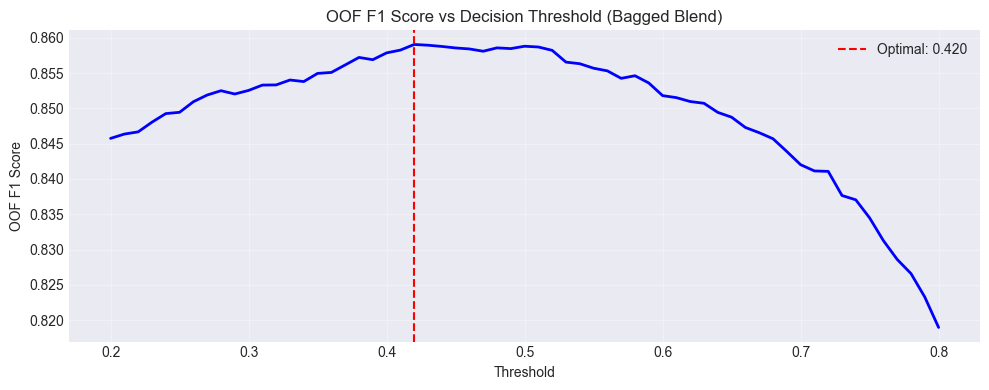

In [76]:
# ============================================================
# OOF THRESHOLD TUNING FOR BAGGED BLEND
# ============================================================
print("=" * 60)
print("OOF THRESHOLD TUNING: Bagged Blend")
print("=" * 60)

X_full = pd.concat([X_train_eng, X_val_eng], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
X_test_blend = X_test_eng.reset_index(drop=True)

ensemble_seeds = [42, 52]
ensemble_models = []
oof_pred_sum = np.zeros(len(X_full), dtype=float)
oof_pred_count = np.zeros(len(X_full), dtype=float)
test_pred_sum = np.zeros(len(X_test_blend), dtype=float)
fold_default_f1 = []

for seed in ensemble_seeds:
    skf_blend = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for fold, (train_idx, val_idx) in enumerate(skf_blend.split(X_full, y_full), start=1):
        X_tr = X_full.iloc[train_idx]
        y_tr = y_full.iloc[train_idx]
        X_va = X_full.iloc[val_idx]
        y_va = y_full.iloc[val_idx]

        fold_imputer = SimpleImputer(strategy='median')
        X_tr_imp_fold = pd.DataFrame(
            fold_imputer.fit_transform(X_tr), columns=eng_feature_cols
        )
        X_va_imp_fold = pd.DataFrame(
            fold_imputer.transform(X_va), columns=eng_feature_cols
        )
        X_te_imp_fold = pd.DataFrame(
            fold_imputer.transform(X_test_blend), columns=eng_feature_cols
        )

        model_store = {}
        val_predictions = {}
        test_predictions = {}

        lgb_model = build_lgbm_model(random_state=seed + fold)
        lgb_model.fit(X_tr_imp_fold, y_tr)
        val_predictions['LightGBM'] = lgb_model.predict_proba(X_va_imp_fold)[:, 1]
        test_predictions['LightGBM'] = lgb_model.predict_proba(X_te_imp_fold)[:, 1]
        model_store['lgbm'] = lgb_model

        xgb_model = build_xgb_model(random_state=seed + fold)
        xgb_model.fit(X_tr_imp_fold, y_tr)
        val_predictions['XGBoost'] = xgb_model.predict_proba(X_va_imp_fold)[:, 1]
        test_predictions['XGBoost'] = xgb_model.predict_proba(X_te_imp_fold)[:, 1]
        model_store['xgb'] = xgb_model

        if 'CatBoost' in gpu_model_weights:
            cat_fold_model = build_cat_model(random_state=seed + fold)
            if cat_fold_model is not None:
                cat_fold_model.fit(X_tr_imp_fold, y_tr)
                val_predictions['CatBoost'] = cat_fold_model.predict_proba(X_va_imp_fold)[:, 1]
                test_predictions['CatBoost'] = cat_fold_model.predict_proba(X_te_imp_fold)[:, 1]
                model_store['cat'] = cat_fold_model

        blend_va = np.zeros(len(X_va_imp_fold), dtype=float)
        blend_test = np.zeros(len(X_te_imp_fold), dtype=float)
        for model_name, weight in gpu_model_weights.items():
            if model_name in val_predictions:
                blend_va += weight * val_predictions[model_name]
                blend_test += weight * test_predictions[model_name]

        oof_pred_sum[val_idx] += blend_va
        oof_pred_count[val_idx] += 1.0
        test_pred_sum += blend_test

        fold_f1 = f1_score(y_va, (blend_va >= 0.5).astype(int))
        fold_default_f1.append(fold_f1)
        ensemble_models.append({
            'seed': seed,
            'fold': fold,
            'imputer': fold_imputer,
            **model_store,
        })
        print(f"Seed {seed} Fold {fold}: default-threshold F1 = {fold_f1:.4f}")

oof_pred = oof_pred_sum / np.maximum(oof_pred_count, 1.0)
y_proba_test = test_pred_sum / len(ensemble_models)
cv_scores = np.array(fold_default_f1)
default_oof_f1 = f1_score(y_full, (oof_pred >= 0.5).astype(int))

thresholds = np.arange(0.20, 0.80, 0.01)
threshold_scores = [f1_score(y_full, (oof_pred >= t).astype(int)) for t in thresholds]
best_threshold_idx = int(np.argmax(threshold_scores))
optimal_threshold = float(thresholds[best_threshold_idx])
f1_optimal = float(threshold_scores[best_threshold_idx])
y_pred_optimal = (oof_pred >= optimal_threshold).astype(int)

best_name = 'BaggedSpatialClimateBlend'
best_model = best_name

print(f"\nDeployment model: {best_name}")
print(f"Blend weights: {gpu_model_weights}")
print(f"Stored ensemble members: {len(ensemble_models)}")
print(f"OOF F1 at default threshold (0.50): {default_oof_f1:.4f}")
print(f"OOF F1 at optimal threshold ({optimal_threshold:.3f}): {f1_optimal:.4f}")
print(f"OOF fold mean F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

plt.figure(figsize=(10, 4))
plt.plot(thresholds, threshold_scores, 'b-', linewidth=2)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal: {optimal_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('OOF F1 Score')
plt.title('OOF F1 Score vs Decision Threshold (Bagged Blend)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE (LightGBM)

Top 25 features:
                       feature  importance
           dist_nearest_neg_km         638
           dist_nearest_pos_km         522
             dist_diff_pos_neg         435
              knn_25_dist_mean         382
               knn_5_dist_mean         373
           knn_25_weighted_occ         356
         spatial_prior_grid050         347
              knn_50_dist_mean         342
           knn_10_weighted_occ         328
  temp_range_knn25_interaction         327
         spatial_prior_grid025         326
               knn_3_dist_mean         324
              knn_10_dist_mean         320
                     ws_dry_cv         306
           knn_50_weighted_occ         289
              knn_occ_mean_avg         279
                   aet_dry_std         275
                 aet_ppt_ratio         271
                     ws_wet_cv         271
         ppt_knn25_interaction         267
        log_dist_ratio_pos_neg         267
      

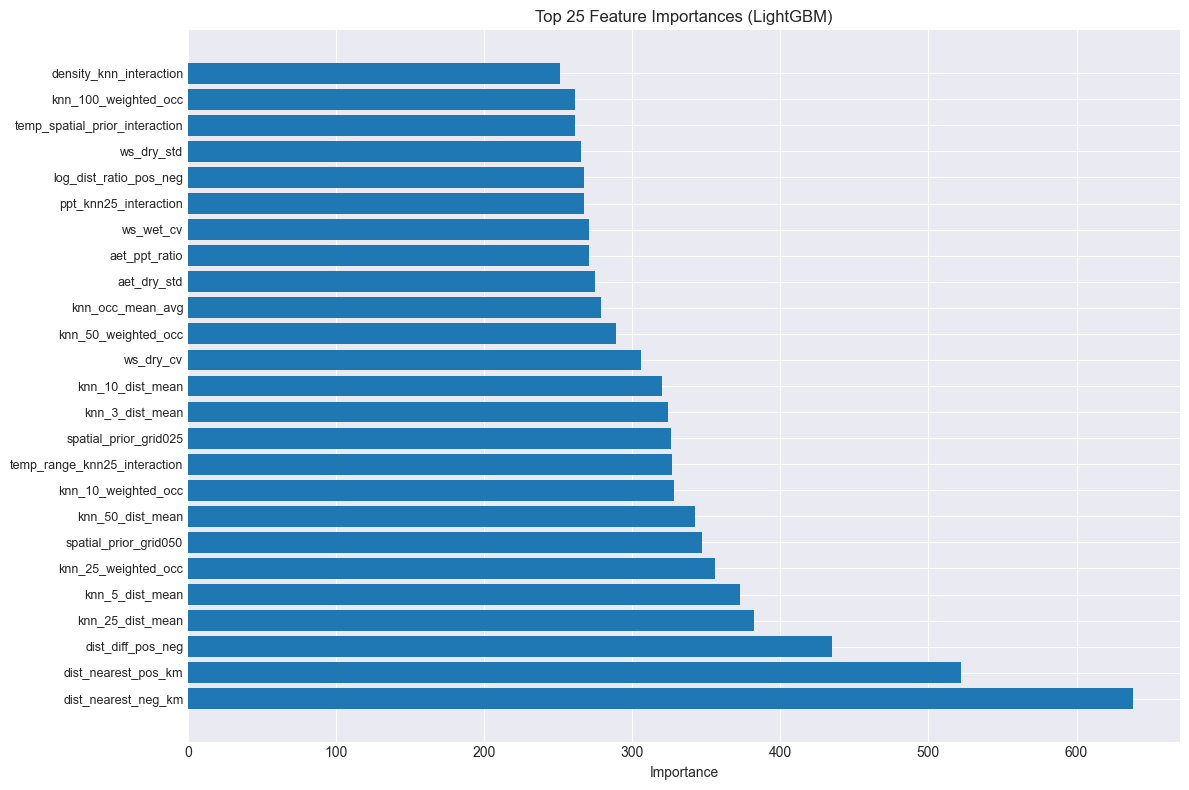

In [77]:
# ============================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================
print("=" * 60)
print("FEATURE IMPORTANCE (LightGBM)")
print("=" * 60)

importance_df = pd.DataFrame({
    'feature': eng_feature_cols,
    'importance': best_lgbm.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 25 features:")
print(importance_df.head(25).to_string(index=False))

plt.figure(figsize=(12, 8))
top_n = min(25, len(importance_df))
plt.barh(range(top_n), importance_df['importance'].head(top_n).values)
plt.yticks(range(top_n), importance_df['feature'].head(top_n).values, fontsize=9)
plt.xlabel('Importance')
plt.title('Top 25 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()

In [78]:
# ============================================================
# FINAL GPU BLEND ENSEMBLE ARTIFACTS
# ============================================================
print("=" * 60)
print("FINAL GPU BLEND ENSEMBLE READY")
print("=" * 60)

final_model = {
    'type': 'repeated_stratified_gpu_blend',
    'name': best_name,
    'weights': gpu_model_weights,
    'seeds': ensemble_seeds,
    'threshold': optimal_threshold,
    'members': ensemble_models,
    'feature_columns': eng_feature_cols,
}

print(f"Deployment model: {best_name}")
print(f"Ensemble members: {len(ensemble_models)}")
print(f"Blend weights: {gpu_model_weights}")
print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"OOF fold F1 mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"OOF F1 at optimal threshold: {f1_optimal:.4f}")

FINAL GPU BLEND ENSEMBLE READY
Deployment model: BaggedSpatialClimateBlend
Ensemble members: 10
Blend weights: {'LightGBM': 0.34090435148093895, 'XGBoost': 0.34055852463388714, 'CatBoost': 0.3185371238851738}
Optimal threshold: 0.420
OOF fold F1 mean: 0.8555 ± 0.0057
OOF F1 at optimal threshold: 0.8590


In [79]:
# ============================================================
# GENERATE TEST PREDICTIONS AND SUBMISSION FILE
# ============================================================
print("=" * 60)
print("GENERATING FINAL SUBMISSION")
print("=" * 60)

# y_proba_test comes from the repeated GPU blend ensemble above
y_pred_test = (y_proba_test >= optimal_threshold).astype(int)

print(f"Deployment model: {best_name}")
print(f"Threshold used: {optimal_threshold:.3f}")
print(f"Ensemble members used: {len(ensemble_models)}")
print(f"Prediction distribution:")
print(f"  No Frog (0): {np.sum(y_pred_test == 0)}")
print(f"  Frog (1):    {np.sum(y_pred_test == 1)}")

submission = pd.DataFrame({
    'ID': test_ids.values,
    'Target': y_pred_test
})

print(f"\nSubmission shape: {submission.shape}")
print(submission.head(10))

submission_file = f'Submission_Final_{best_name}_t{optimal_threshold:.2f}.csv'
submission.to_csv(submission_file, index=False)
print(f"\n✓ Submission saved: {submission_file}")

submission.to_csv('Predicted_Data.csv', index=False)
print("✓ Also saved as: Predicted_Data.csv")

GENERATING FINAL SUBMISSION
Deployment model: BaggedSpatialClimateBlend
Threshold used: 0.420
Ensemble members used: 10
Prediction distribution:
  No Frog (0): 650
  Frog (1):    1350

Submission shape: (2000, 2)
             ID  Target
0  ID_TS_54240C       1
1  ID_TS_EF9635       0
2  ID_TS_4E63E6       0
3  ID_TS_FDAB8E       0
4  ID_TS_E00D49       0
5  ID_TS_A52A64       0
6  ID_TS_CFB5DB       1
7  ID_TS_CA468C       1
8  ID_TS_52FAAF       0
9  ID_TS_08039A       1

✓ Submission saved: Submission_Final_BaggedSpatialClimateBlend_t0.42.csv
✓ Also saved as: Predicted_Data.csv


In [80]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"\nValidation Model Comparison:")
print(f"  LightGBM (Optuna):      F1 = {f1_lgbm:.4f}")
print(f"  XGBoost  (Optuna):      F1 = {f1_xgb:.4f}")
if np.isfinite(f1_cat):
    print(f"  CatBoost:               F1 = {f1_cat:.4f}")
print(f"  Random Forest:          F1 = {f1_rf:.4f}")
print(f"  Stacking Ensemble:      F1 = {f1_stack:.4f}")

print(f"\nDeployment Model: {best_name}")
print(f"Blend weights: {gpu_model_weights}")
print(f"Optimal Threshold: {optimal_threshold:.3f}")
print(f"OOF Fold F1 Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"OOF F1 at Optimal Threshold: {f1_optimal:.4f}")
print(f"Ensemble members: {len(ensemble_models)}")
print(f"Submission file: {submission_file}")

joblib.dump(final_model, f'final_model_{best_name}.pkl')
joblib.dump(eng_feature_cols, 'final_feature_cols.pkl')
print("\n✓ Model artifacts saved")
print("=" * 60)

FINAL SUMMARY

Validation Model Comparison:
  LightGBM (Optuna):      F1 = 0.8640
  XGBoost  (Optuna):      F1 = 0.8635
  CatBoost:               F1 = 0.8351
  Random Forest:          F1 = 0.8598
  Stacking Ensemble:      F1 = 0.8680

Deployment Model: BaggedSpatialClimateBlend
Blend weights: {'LightGBM': 0.34090435148093895, 'XGBoost': 0.34055852463388714, 'CatBoost': 0.3185371238851738}
Optimal Threshold: 0.420
OOF Fold F1 Mean: 0.8555 ± 0.0057
OOF F1 at Optimal Threshold: 0.8590
Ensemble members: 10
Submission file: Submission_Final_BaggedSpatialClimateBlend_t0.42.csv

✓ Model artifacts saved


## (Optional) Additional Analysis Below
The cells below are kept for reference and are NOT needed for the main pipeline above.

In [81]:
print(f"LightGBM best F1: {study.best_value:.4f}")
print(f"XGBoost best F1: {study_xgb.best_value:.4f}")
print(f"Eng features: {len(eng_feature_cols)}")
print(f"X_train_imp shape: {X_train_imp.shape}")
print(f"X_val_imp shape: {X_val_imp.shape}")

LightGBM best F1: 0.8548
XGBoost best F1: 0.8559
Eng features: 355
X_train_imp shape: (5049, 355)
X_val_imp shape: (1263, 355)


In [82]:
# (Legacy) Quick model comparison — already done above
print("See model comparison in the main pipeline above.")

See model comparison in the main pipeline above.


In [83]:
# (Legacy) Feature importance — already plotted above
print("See feature importance chart in the main pipeline above.")

See feature importance chart in the main pipeline above.


---
### Legacy cells below (predictions and submissions already generated above)

In [84]:
print("Predictions already generated. See Predicted_Data.csv")

Predictions already generated. See Predicted_Data.csv


## Section 9: Create and Save Submission File

Format predictions into the required submission format.

In [85]:
print("Submission already saved. See above.")

Submission already saved. See above.


In [86]:
print("Model artifacts already saved. See above.")

Model artifacts already saved. See above.


## Summary

### Pipeline Overview
1. Load training/test CSVs
2. Extract **all** TerraClimate bands (median + std) from GeoTIFF
3. Add **spatial KNN occurrence features** from nearby labeled records
4. Feature engineering: geographic encoding, hydrology and temperature ratios, aggregate stats, temporal CV
5. **Optuna** hyperparameter tuning for LightGBM and XGBoost
6. Random Forest and stacking used as comparison models
7. Build a **GPU deployment blend** from LightGBM + XGBoost
8. Use **repeated stratified folds** to create out-of-fold probabilities and average test probabilities
9. Tune the final decision threshold on the blend's OOF predictions
10. Generate submission with the optimized threshold

### Key Improvements In This Version
- Keeps the strong **spatial KNN** signal in the feature set
- Adds more **domain-driven climate interactions** and ratios
- Runs both **LightGBM and XGBoost on GPU**
- Uses a more robust **repeated fold ensemble** instead of deploying a single refit model
- Tunes threshold on **OOF blended probabilities**, which is more stable than a single validation split

---
### Legacy iteration cells below (kept for reference only, do NOT run)

In [87]:
# Legacy: Old threshold tuning iteration (superseded by CV-based tuning above)
pass

In [88]:
# Legacy: Old iteration 4 submission
pass

In [89]:
# Legacy: Old iteration 5 submission
pass

In [90]:
# Legacy: Old SMOTE iteration
pass

In [91]:
# Legacy: Old SMOTE submission
pass